# Ejemplo de red neuronal

In [7]:
import numpy as np

In [8]:
nn_0=2
nn_1=2
nn_2=2

b1 = np.array([[0.45], [0.35]])
W1 = np.array([[0.15, 0.20], [0.25, 0.30]])
b2 = np.array([[0.30], [0.45]])
W2 = np.array([[0.35, 0.48], [0.40, 0.45]])

Z1 = np.zeros((nn_1, 1))
A1 = np.zeros((nn_1, 1))
Z2 = np.zeros((nn_2, 1))
A2 = np.zeros((nn_2, 1))

Se define la topologia de la red, valores de sesgos y pesos de manera arbitraria, y tambien los vectores de propagacion de la red.

In [9]:
def propaga(Xo):    # Funcion de propagacion hacia adelante
    Z1 = np.dot(W1, Xo) + b1
    A1 = sig(Z1)
    Z2 = np.dot(W2, A1) + b1
    A2 = sig(Z2)
    #print("A2 = ", A2)
    return A2, Z2, A1, Z1

def sig(s):         # Funcion de activacion sigmoidal
    return 1/(1+np.exp(-s))

def dSig(s):
    df = sig(s.T[0])*(sig(s.T[0]))
    ds = np.diag(df)
    return ds

In [10]:
X = np.array([[0.05], [0.10]])
Yr = np.array([[0.01], [0.99]])

A2, Z2, A1, Z1 = propaga(X)
print(A2)

[[0.72161959]
 [0.70380033]]


In [11]:
def error(A2, Yd):
    err = Yd - A2
    return err

---

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

# Semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.21.0


In [13]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Datos de entrenamiento: {x_train.shape}, etiquetas: {y_train.shape}")
print(f"Datos de prueba: {x_test.shape}, etiquetas: {y_test.shape}")
print(f"Rango de valores de píxeles: [{x_train.min()}, {x_train.max()}]")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Datos de entrenamiento: (60000, 28, 28), etiquetas: (60000,)
Datos de prueba: (10000, 28, 28), etiquetas: (10000,)
Rango de valores de píxeles: [0, 255]


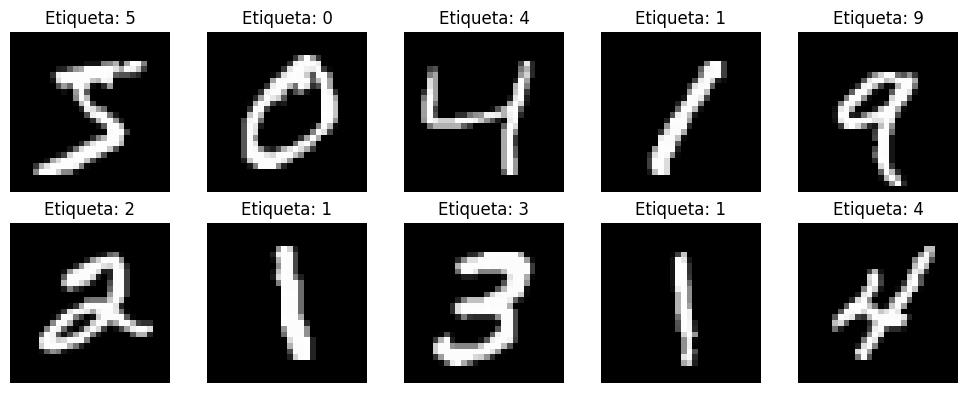

In [14]:
# Visualizar algunos ejemplos
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Etiqueta: {y_train[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [15]:
# Normalización
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Aplanar imágenes 28x28 -> 784
x_train_flat = x_train.reshape((x_train.shape[0], 28 * 28))
x_test_flat = x_test.reshape((x_test.shape[0], 28 * 28))

print("Forma final de entrenamiento:", x_train_flat.shape)
print("Forma final de prueba:", x_test_flat.shape)

Forma final de entrenamiento: (60000, 784)
Forma final de prueba: (10000, 784)


In [16]:
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    x_train_flat, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8528 - loss: 0.4874 - val_accuracy: 0.9608 - val_loss: 0.1473
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9389 - loss: 0.2089 - val_accuracy: 0.9672 - val_loss: 0.1155
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9526 - loss: 0.1588 - val_accuracy: 0.9718 - val_loss: 0.0961
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9616 - loss: 0.1274 - val_accuracy: 0.9735 - val_loss: 0.0844
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9666 - loss: 0.1109 - val_accuracy: 0.9743 - val_loss: 0.0827
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9695 - loss: 0.0977 - val_accuracy: 0.9755 - val_loss: 0.0757
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9725 - loss: 0.0887 - val_accuracy: 0.9780 - val_loss: 0.0723
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9746 - loss: 0.0794 - val_accuracy: 0.

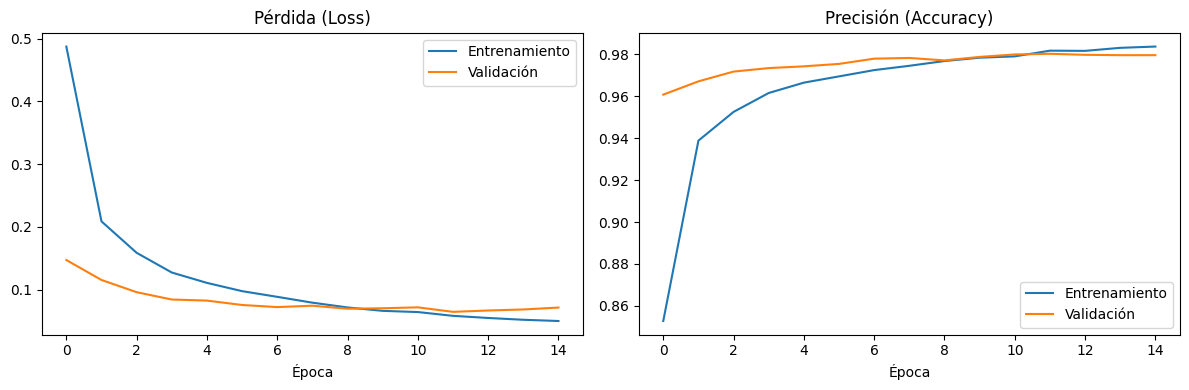

In [18]:
# Graficar curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Entrenamiento")
axes[0].plot(history.history["val_loss"], label="Validación")
axes[0].set_title("Pérdida (Loss)")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Entrenamiento")
axes[1].plot(history.history["val_accuracy"], label="Validación")
axes[1].set_title("Precisión (Accuracy)")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
test_loss, test_acc = model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Pérdida en test: {test_loss:.4f}")
print(f"Precisión en test: {test_acc:.4f} ({test_acc*100:.2f}%)")

Pérdida en test: 0.0700
Precisión en test: 0.9800 (98.00%)


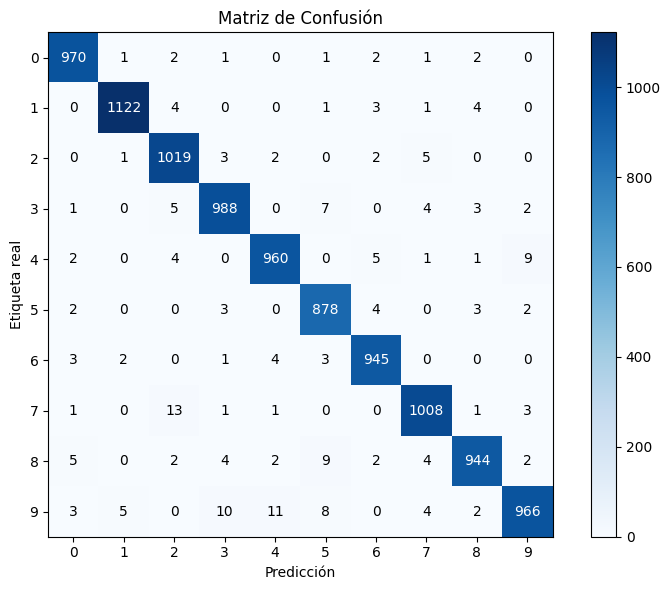

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.98      0.98       892
           6       0.98      0.99      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [20]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(x_test_flat, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.colorbar()
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")
plt.xticks(range(10))
plt.yticks(range(10))
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred))

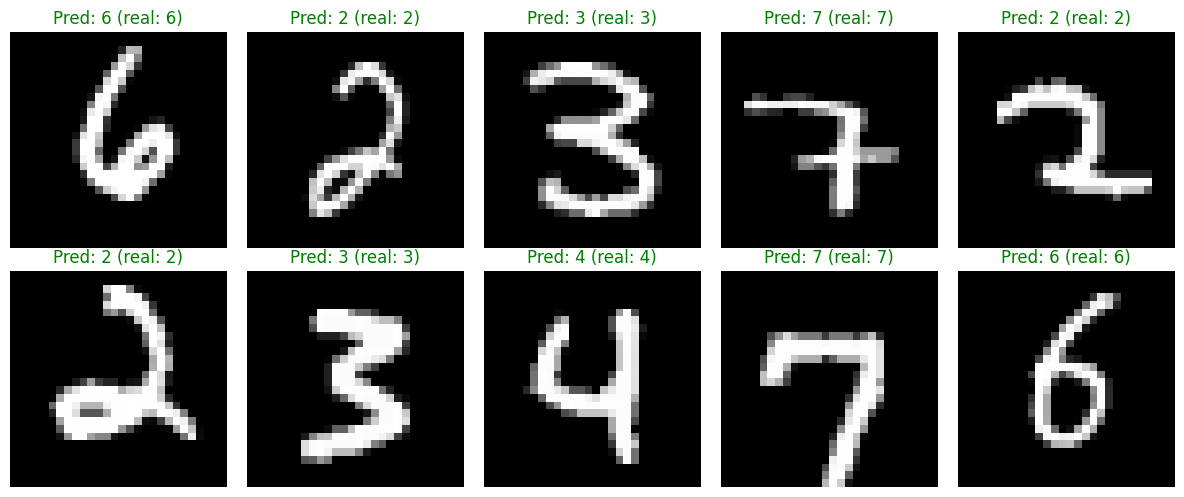

In [21]:
n = 10
indices = np.random.choice(len(x_test), n, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in zip(indices, axes.flat):
    pred = y_pred[idx]
    real = y_test[idx]
    color = "green" if pred == real else "red"
    ax.imshow(x_test[idx], cmap="gray")
    ax.set_title(f"Pred: {pred} (real: {real})", color=color)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [22]:
def predecir_digito(imagen):
    """
    Recibe una imagen 28x28 (valores 0-255 o 0-1) y devuelve
    el dígito predicho junto con las probabilidades de cada clase.
    """
    img = np.array(imagen, dtype="float32")
    if img.max() > 1.0:
        img = img / 255.0
    img_flat = img.reshape(1, 784)
    probs = model.predict(img_flat, verbose=0)[0]
    digito = int(np.argmax(probs))
    return digito, probs

# Ejemplo de uso con una imagen del set de prueba
ejemplo_idx = 0
digito, probs = predecir_digito(x_test[ejemplo_idx])
print(f"Dígito predicho: {digito}")
print(f"Probabilidad: {probs[digito]*100:.2f}%")

Dígito predicho: 7
Probabilidad: 100.00%
